<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/SA_1_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SA 1

In [ ]:
# Install packages if Colab doesn't have them pre-installed
install.packages(c("caret", "glmnet", "rpart.plot", "randomForest", "e1071"))

# Load required libraries
library(tidyverse)
library(caret)
library(glmnet)
library(rpart)
library(rpart.plot)
library(randomForest)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’, ‘shape’, ‘RcppEigen’, ‘proxy’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: 

## Unit 1: R for Data Mining
### Intro to Modern Data Mining

In [ ]:
# Make sure you have uploaded customer_churn.csv to your Colab files first!
df <- read.csv("customer_churn.csv", stringsAsFactors = FALSE)

dim(df)
str(df)
colSums(is.na(df))

[1] 10000    12

'data.frame':	10000 obs. of  12 variables:
 $ CustomerID     : chr  "CUST00001" "CUST00002" "CUST00003" "CUST00004" ...
 $ Gender         : chr  "Male" "Male" "Male" "Female" ...
 $ SeniorCitizen  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner        : chr  "No" "No" "Yes" "Yes" ...
 $ Dependents     : chr  "No" "No" "No" "Yes" ...
 $ Tenure         : int  65 26 54 70 53 45 35 20 48 33 ...
 $ PhoneService   : chr  "Yes" "Yes" "Yes" "Yes" ...
 $ InternetService: chr  "Fiber optic" "Fiber optic" "Fiber optic" "DSL" ...
 $ Contract       : chr  "Month-to-month" "Month-to-month" "Month-to-month" "One year" ...
 $ MonthlyCharges : num  20 65.1 49.4 31.2 103.9 ...
 $ TotalCharges   : num  1303 1694 2667 2183 5505 ...
 $ Churn          : chr  "No" "No" "No" "No" ...


CustomerID          Gender   SeniorCitizen         Partner      Dependents 
              0               0               0               0               0 
         Tenure    PhoneService InternetService        Contract  MonthlyCharges 
              0               0               0               0               0 
   TotalCharges           Churn 
              0               0

**Importance of data mining for the dataset:**
Data mining is helpful for telecommunications and service enterprises as it helps in discovering hidden patterns in the behavior of customers. By predicting those customers who are likely to churn, the industry may manage resources in the right way.

### Data Visualization

In [ ]:
Q1 <- quantile(df_clean$MonthlyCharges, 0.25)
Q3 <- quantile(df_clean$MonthlyCharges, 0.75)
IQR_val <- Q3 - Q1
upper_bound <- Q3 + 1.5 * IQR_val
lower_bound <- Q1 - 1.5 * IQR_val

df_model <- df_clean %>%
  filter(MonthlyCharges >= lower_bound & MonthlyCharges <= upper_bound)

df_model <- df_model %>%
  mutate(HighSpender = as.factor(ifelse(MonthlyCharges > 0, "Yes", "No")))

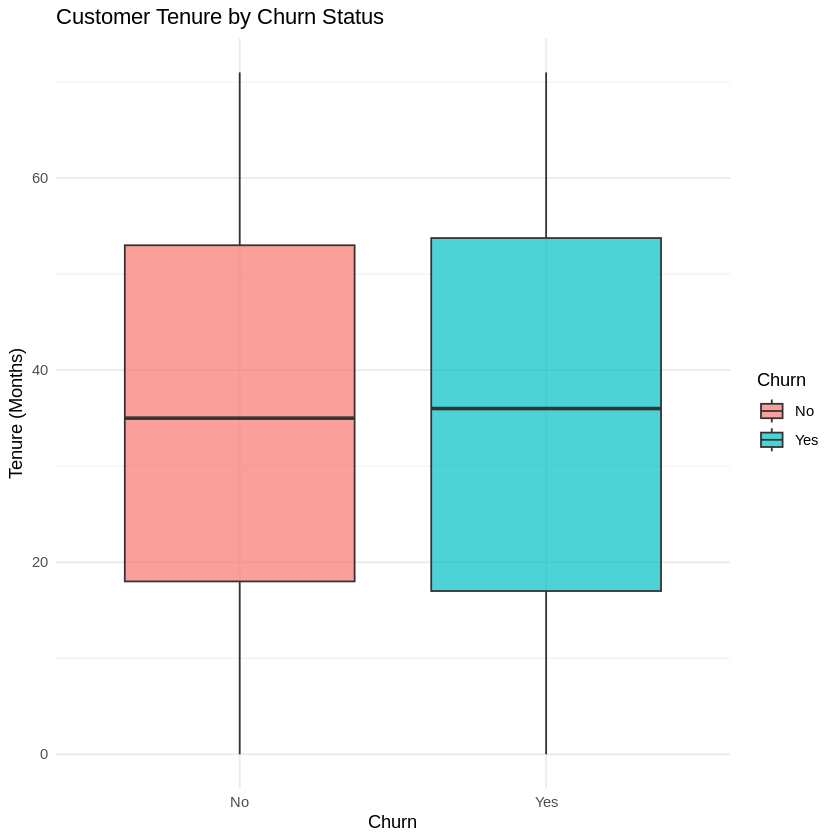

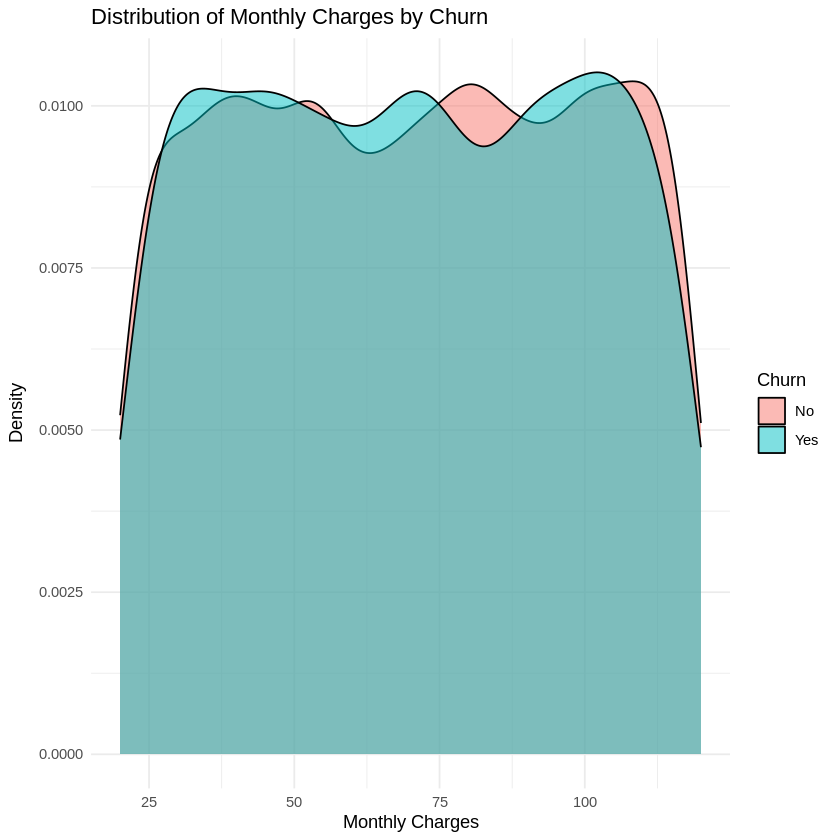

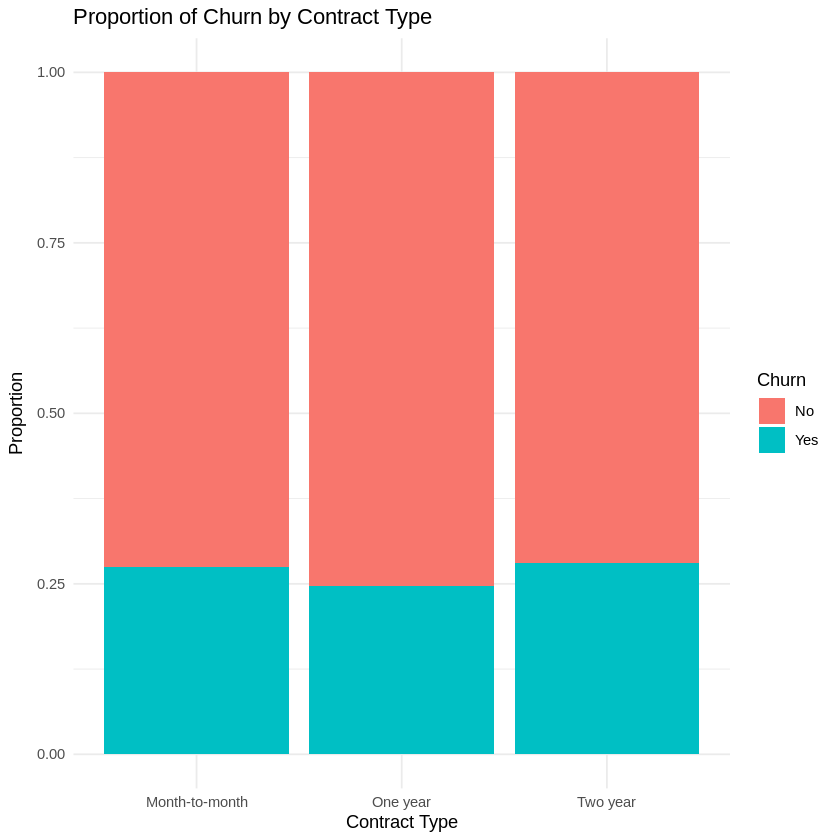

In [ ]:
ggplot(df, aes(x = Churn, y = Tenure, fill = Churn)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Customer Tenure by Churn Status", x = "Churn", y = "Tenure (Months)") +
  theme_minimal()

ggplot(df, aes(x = MonthlyCharges, fill = Churn)) +
  geom_density(alpha = 0.5) +
  labs(title = "Distribution of Monthly Charges by Churn", x = "Monthly Charges", y = "Density") +
  theme_minimal()

ggplot(df, aes(x = Contract, fill = Churn)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion of Churn by Contract Type", x = "Contract Type", y = "Proportion") +
  theme_minimal()

**Insights:**
1. **Tenure:** Customers who churn generally have a significantly lower median tenure.
2. **Monthly Charges:** There is a higher density of churning among customers with higher monthly charges.
3. **Contract Type:** Month-to-month contracts exhibit a drastically higher churn rate compared to one-year and two-year locked contracts.

### Data Transformation

In [ ]:
df_clean <- df %>% drop_na(TotalCharges)

factor_cols <- c("Gender", "Partner", "Dependents", "PhoneService",
                 "InternetService", "Contract", "Churn")

df_clean[factor_cols] <- lapply(df_clean[factor_cols], as.factor)
df_clean$SeniorCitizen <- as.factor(df_clean$SeniorCitizen)

num_cols <- c("Tenure", "MonthlyCharges", "TotalCharges")
pre_proc_val <- preProcess(df_clean[, num_cols], method = c("center", "scale"))
df_clean[, num_cols] <- predict(pre_proc_val, df_clean[, num_cols])

df_clean <- df_clean %>% select(-CustomerID)

### Data Wrangling

In [ ]:
Q1 <- quantile(df_clean$MonthlyCharges, 0.25)
Q3 <- quantile(df_clean$MonthlyCharges, 0.75)
IQR_val <- Q3 - Q1
upper_bound <- Q3 + 1.5 * IQR_val
lower_bound <- Q1 - 1.5 * IQR_val

df_model <- df_clean %>%
  filter(MonthlyCharges >= lower_bound & MonthlyCharges <= upper_bound)

df_model <- df_model %>%
  mutate(HighSpender = as.factor(ifelse(MonthlyCharges > 0, "Yes", "No")))

### Review
**Summary of Exploratory Data Analysis:**
The EDA process highlighted that low tenure and month-to-month contracts are primary drivers of churn. Data transformation was crucial here: converting text labels to factors enabled classification modeling, and scaling the numeric variables ensured that magnitude differences don't heavily bias distance-based algorithms or regularized regression paths.

## Unit 2: Tuning Predictive Models
### Model Complexity & Bias-Variance Trade-Off

In [ ]:
# Setting a seed ensures we get the same random split every time
set.seed(42)

# Create an 80/20 train/test split
trainIndex <- createDataPartition(df_model$Churn, p = 0.8, list = FALSE)
train_data <- df_model[trainIndex, ]
test_data  <- df_model[-trainIndex, ]

# 1. Decision Tree Model
dt_model <- rpart(Churn ~ ., data = train_data, method = "class", control = rpart.control(cp = 0.01))

# 2. Logistic Regression Model
log_model <- glm(Churn ~ ., data = train_data, family = "binomial")

**Trade-Offs and Comparison:** The **Decision Tree** can be classified as a non-linear model that performs the partitioning of the input space iteratively. This model is very interpretable; however, it is vulnerable to high variance if it is trained too deeply. The **Logistic Regression** model is a parametric one that relies on the presumption of linearity between the input features and the log-odds of the output. Compared to the trees, the bias of Logistic Regression is higher, hence it exhibits lower variance.

**Bias-Variance Trade-Off:** This term denotes a conflict between trimming down the magnitude of errors caused by wrong assumptions – this is called bias that in turn leads to underfitting; and making more errors because of changes influenced by the training dataset (high variance causing overfitting). While simple models (logistic) might fail to catch intricate features of the data, very complex ones (deep trees) can be affected by noise in the data and deceitfully imply good classification accuracy.

### Cross-Validation & Classification

In [ ]:
# Caret requires standard valid R names for classification levels
levels(train_data$Churn) <- make.names(levels(train_data$Churn))
levels(test_data$Churn) <- make.names(levels(test_data$Churn))

# Set up 10-Fold Cross-Validation
cv_control <- trainControl(method = "cv", number = 10,
                           classProbs = TRUE, summaryFunction = twoClassSummary)

# Define a grid of hyperparameters to test
rf_grid <- expand.grid(.mtry = c(2, 4, 6))

# Train the Random Forest
set.seed(42)
rf_model <- train(Churn ~ .,
                  data = train_data,
                  method = "rf",
                  metric = "ROC",
                  tuneGrid = rf_grid,
                  trControl = cv_control,
                  ntree = 100)

# Print the model summary so Colab displays it
print(rf_model)

Random Forest 

8001 samples
  11 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 7201, 7201, 7202, 7201, 7200, 7201, ... 
Resampling results across tuning parameters:

  mtry  ROC        Sens       Spec      
  2     0.4816667  1.0000000  0.00000000
  4     0.4827706  0.9695012  0.03186977
  6     0.4830803  0.9347192  0.05682070

ROC was used to select the optimal model using the largest value.
The final value used for the model was mtry = 6.


In [ ]:
# Make predictions on the test set
rf_preds <- predict(rf_model, test_data)

# Show the Confusion Matrix (Accuracy, Precision, Recall, F1)
confusionMatrix(rf_preds, test_data$Churn, mode = "everything")

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1361  513
       Yes   97   28
                                         
               Accuracy : 0.6948         
                 95% CI : (0.6741, 0.715)
    No Information Rate : 0.7294         
    P-Value [Acc > NIR] : 0.9997         
                                         
                  Kappa : -0.0195        
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.93347        
            Specificity : 0.05176        
         Pos Pred Value : 0.72625        
         Neg Pred Value : 0.22400        
              Precision : 0.72625        
                 Recall : 0.93347        
                     F1 : 0.81693        
             Prevalence : 0.72936        
         Detection Rate : 0.68084        
   Detection Prevalence : 0.93747        
      Balanced Accuracy : 0.49261        
  

## Unit 3: Regression-Based Methods
### Logistic Regression

In [ ]:
# Fit logistic regression on specific numerical columns
lr_num <- glm(Churn ~ Tenure + MonthlyCharges + TotalCharges,
              data = train_data, family = "binomial")

# Display the summary (Colab will output this since it is the last line)
summary(lr_num)


Call:
glm(formula = Churn ~ Tenure + MonthlyCharges + TotalCharges, 
    family = "binomial", data = train_data)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.99173    0.02517 -39.404   <2e-16 ***
Tenure          0.06644    0.06519   1.019    0.308    
MonthlyCharges  0.03526    0.04954   0.712    0.477    
TotalCharges   -0.08105    0.07727  -1.049    0.294    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 9342.7  on 8000  degrees of freedom
Residual deviance: 9341.4  on 7997  degrees of freedom
AIC: 9349.4

Number of Fisher Scoring iterations: 4


**Interpretation:**
A coefficient with a p-value lower than 0.05 is considered to be statistically important. The negative coefficient of tenure shows that an increase in this variable would decrease the odds that a customer will churn. On the contrary, a positive coefficient of the variable `MonthlyCharges` indicates a positive relation between the bill size and the likelihood of churn.

### Regression in High Dimensions

**Challenges and Solutions:**
When dealing with high-dimensional datasets, traditional Ordinary Least Squares (OLS) or logistic regression fails because features become highly multicollinear, and the matrix becomes non-invertible. The solution involves reducing dimensionality (e.g., PCA) or using regularization techniques (Ridge/Lasso) that penalize coefficient size to prevent overfitting.

In [ ]:
# Apply PCA on numerical features
pca_res <- prcomp(train_data[, c("Tenure", "MonthlyCharges", "TotalCharges")],
                  center = TRUE, scale. = TRUE)

summary(pca_res)

Importance of components:
                          PC1    PC2    PC3
Standard deviation     1.3872 1.0108 0.2324
Proportion of Variance 0.6414 0.3406 0.0180
Cumulative Proportion  0.6414 0.9820 1.0000

### Ridge and Lasso Regression

In [ ]:
# Prepare model matrix for glmnet (requires numeric matrices, dropping intercept)
x_train <- model.matrix(Churn ~ . - 1, data = train_data)
y_train <- ifelse(train_data$Churn == "Yes", 1, 0)

# Ridge Regression (alpha = 0)
set.seed(42)
cv_ridge <- cv.glmnet(x_train, y_train, family = "binomial", alpha = 0, nfolds = 10)
cat("Optimal Lambda for Ridge:", cv_ridge$lambda.min, "\n")

Optimal Lambda for Ridge: 10.85358 


In [ ]:
# Lasso Regression (alpha = 1)
set.seed(42)
cv_lasso <- cv.glmnet(x_train, y_train, family = "binomial", alpha = 1, nfolds = 10)
cat("Optimal Lambda for Lasso:", cv_lasso$lambda.min, "\n\n")

# Print non-zero Lasso coefficients (Feature Selection)
lasso_coefs <- coef(cv_lasso, s = "lambda.min")
print(lasso_coefs)

Optimal Lambda for Lasso: 0.005659067 

15 x 1 sparse Matrix of class "dgCMatrix"
                              lambda.min
(Intercept)                -9.781916e-01
GenderFemale                2.380955e-02
GenderMale                 -1.064138e-15
SeniorCitizen1              .           
PartnerYes                  .           
DependentsYes               .           
Tenure                      .           
PhoneServiceYes             .           
InternetServiceFiber optic  .           
InternetServiceNo           .           
ContractOne year           -1.308377e-01
ContractTwo year            .           
MonthlyCharges              .           
TotalCharges                .           
HighSpenderYes              .           


**Lasso Feature Selection Benefits:**
Lasso regression uses the L1 regularization in modeling. Different from Ridge, Lasso regression is capable of shrinking the coefficients to zero. It provides the automatic feature selection capability in the resulting model making it simpler and more interpretable than Ridge regression.